In [1]:
install.packages("sqldf")
install.packages("ggplot2")

library(sqldf)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



In [9]:
events <- read.csv('/content/app_events.csv')
complaints <- read.csv('/content/complaints.csv')

In [10]:
sqldf("SELECT zone_context, COUNT(*) AS total FROM events GROUP BY zone_context")

zone_context,total
<chr>,<int>
AIRPORT,43
Airport,44
CENTRAL,26
Central,24
Ctr,43
EAST,40
East,51
NORTH,33
North,29


In [11]:
sqldf(" SELECT zone_context, AVG(api_latency_ms) AS avg_latency FROM events GROUP BY zone_context")

zone_context,avg_latency
<chr>,<dbl>
AIRPORT,666.6512
Airport,546.8864
CENTRAL,515.2692
Central,522.1667
Ctr,489.3488
EAST,460.0750
East,414.8235
NORTH,415.8788
North,452.5172


In [12]:
sqldf("SELECT * FROM events WHERE success_flag = 0")

event_id,customer_id,order_id,event_timestamp,event_type,session_id,device_type,zone_context,api_latency_ms,success_flag
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>
AE00013,C0479,O00414,2024-05-28 15:11:00,chat_escalated,S37114,Web,WEST,399,0
AE00017,C0170,O00424,2024-04-04 06:22:00,chat_escalated,S30048,Android,North,624,0
AE00036,C0007,O00977,2025-05-03 17:47:00,chat_escalated,S19561,iOS,Ctr,362,0
AE00048,C0306,O01222,2025-02-25 04:16:00,chat_escalated,S77519,Android,RiverSide,166,0
AE00052,C0326,O01080,2024-02-12 02:37:00,payment_retry,S42021,Android,north,570,0
AE00056,C0556,O01180,2025-09-23 17:24:00,payment_retry,S77071,Android,north,592,0
AE00066,C0612,,2025-05-19 07:41:00,payment_retry,S90136,Android,RiverSide,60,0
AE00069,C0303,,2025-02-13 15:13:00,payment_retry,S60656,Android,South,637,0
AE00097,C0468,O00460,2025-06-10 04:05:00,payment_retry,S77602,Android,Riverside,404,0


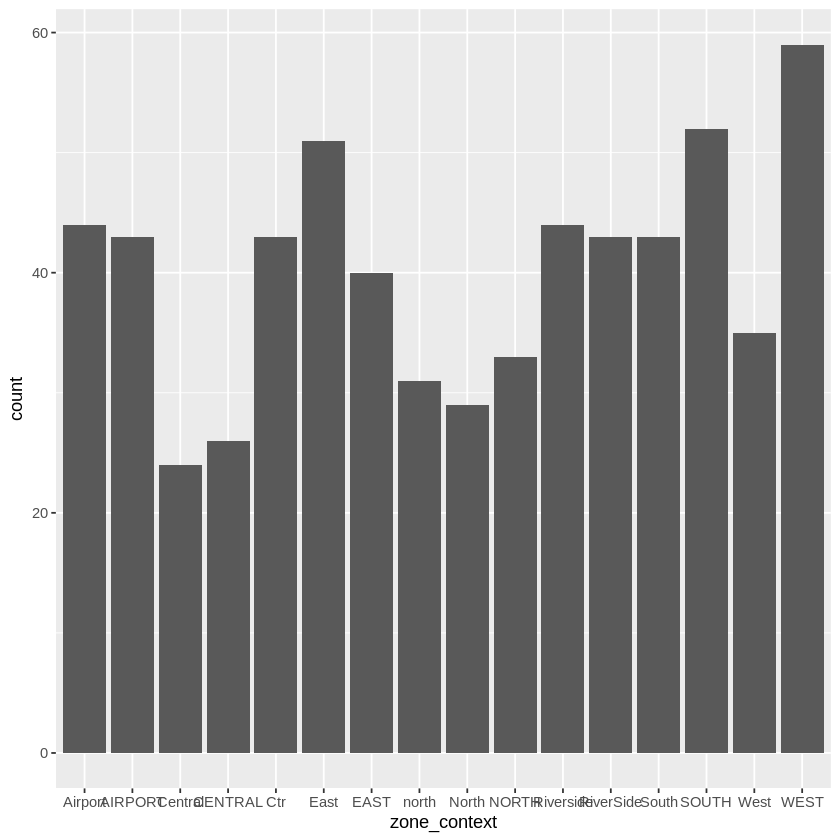

In [13]:
ggplot(events, aes(x=zone_context)) + geom_bar()

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


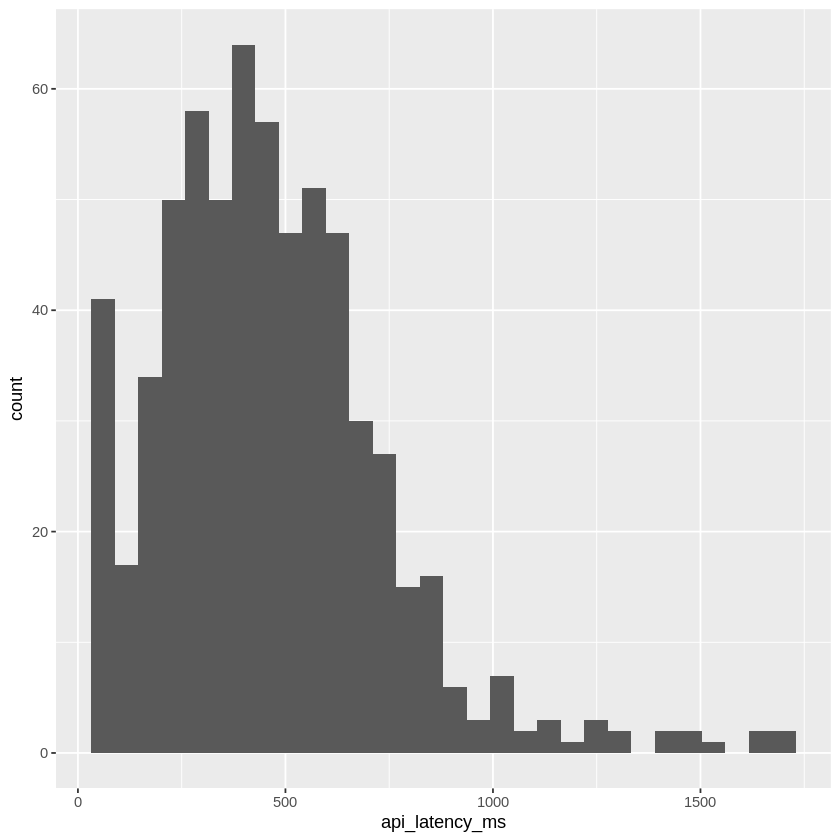

In [14]:
ggplot(events, aes(x=api_latency_ms)) + geom_histogram()